### Big Data Analytics (LD7186) — Section 1

In [ ]:
# !pip -q install pandas numpy matplotlib seaborn scipy statsmodels openpyxl

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [ ]:
DATA_PATH = Path("Accidental_Drug_Related_Deaths_2012-2024.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Current folder:", Path.cwd())
print("Looking for:", DATA_PATH.resolve())
print("Outputs will be saved to:", OUTPUT_DIR.resolve())

Current folder: c:\Users\Admin\Desktop\work\Worktech\big data
Looking for: C:\Users\Admin\Desktop\work\Worktech\big data\Accidental_Drug_Related_Deaths_2012-2024.csv
Outputs will be saved to: C:\Users\Admin\Desktop\work\Worktech\big data\outputs


In [ ]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
print("Columns:", len(df_raw.columns))
display(df_raw.head(3))

# Strip whitespace from column names
df_raw.columns = [c.strip() for c in df_raw.columns]

print("\nAfter stripping column names:")
print("Columns:", len(df_raw.columns))
print(df_raw.columns.tolist())

Shape: (12963, 48)
Columns: 48


,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,Injury County,Injury State,Injury Place,Description of Injury,Death City,Death County,Death State,Location,Location if Other,Cause of Death,Manner of Death,Other Significant Conditions,Heroin,Heroin death certificate (DC),Cocaine,Fentanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,Benzodiazepine,Methadone,Meth/Amphetamine,Amphet,Tramad,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo
0,01/02/2023,Date of death,65.0,Male,White,"No, not Spanish/Hispanic/Latino",BRIDGEPORT,FAIRFIELD,CT,BRIDGEPORT,FAIRFIELD,NaN,Other,Substance use,NaN,NaN,NaN,NaN,NaN,Acute Intoxication by the Combined Effects of ...,Accident,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,"BRIDGEPORT, CT\n(41.179195, -73.189476)","BRIDGEPORT, CT\n(41.179195, -73.189476)","CT\n(41.57350273, -72.738305908)"
1,01/18/2023,Date of death,42.0,Male,White,"No, not Spanish/Hispanic/Latino",WATERBURY,NEW HAVEN,CT,FARMINGTON,HARTFORD,CT,Home,Ethanol and Fentanyl Use,NaN,NaN,NaN,NaN,NaN,Combined Effects of Fentanyl and Ethanol Toxicity,Accident,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,"WATERBURY, CT\n(41.5542609, -73.0430692)","FARMINGTON, CT\n(41.726536, -72.8250564)","CT\n(41.57350273, -72.738305908)"
2,01/26/2022,Date of death,34.0,Male,White,NaN,BROOKFIELD,FAIRFIELD,CT,BROOKFIELD,FAIRFIELD,CT,Home,Substance Abuse,NaN,NaN,NaN,Decedent’s Home,NaN,Acute Intoxication due to the Combined Effects...,Accident,NaN,Y,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,Y,NaN,Y,NaN,"BROOKFIELD, CT\n(41.46736000000004, -73.398259...","BROOKFIELD, CT\n(41.46736000000004, -73.398259...","CT\n(41.57350273000003, -72.73830590799997)"



After stripping column names:
Columns: 48
['Date', 'Date Type', 'Age', 'Sex', 'Race', 'Ethnicity', 'Residence City', 'Residence County', 'Residence State', 'Injury City', 'Injury County', 'Injury State', 'Injury Place', 'Description of Injury', 'Death City', 'Death County', 'Death State', 'Location', 'Location if Other', 'Cause of Death', 'Manner of Death', 'Other Significant Conditions', 'Heroin', 'Heroin death certificate (DC)', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other', 'ResidenceCityGeo', 'InjuryCityGeo', 'DeathCityGeo']


In [ ]:
# Substance columns in the dataset
SUBSTANCE_COLS = [
    "Heroin", "Heroin death certificate (DC)", "Cocaine", "Fentanyl", "Fentanyl Analogue",
    "Oxycodone", "Oxymorphone", "Ethanol", "Hydrocodone", "Benzodiazepine", "Methadone",
    "Meth/Amphetamine", "Amphet", "Tramad", "Hydromorphone", "Morphine (Not Heroin)",
    "Xylazine", "Gabapentin", "Opiate NOS", "Heroin/Morph/Codeine", "Other Opioid", "Any Opioid", "Other"
]

def detect_yes(x) -> int:
    """Convert values like 'Y', 'Y POPS', 'Y (PTCH)' to 1; else 0."""
    if pd.isna(x):
        return 0
    s = str(x).strip().upper()
    return 1 if s.startswith("Y") else 0

def save_fig(filename: str):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)

def pct(x):
    return f"{x*100:.1f}%"

In [ ]:
df = df_raw.copy()

# Parse Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", format="%m/%d/%Y")

# Year / Month for time analysis
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

# Age cleaning
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df.loc[(df["Age"] < 0) | (df["Age"] > 110), "Age"] = np.nan

# Standardize Sex
df["Sex"] = df["Sex"].fillna("Unknown").replace({"X": "Unknown"}).str.strip()

# Standardize Race (light cleaning)
df["Race"] = df["Race"].fillna("Unknown").str.strip()
df["Race"] = df["Race"].replace({
    "white": "White",
    "Black": "Black or African American"
})

# Ethnicity group
df["Ethnicity"] = df["Ethnicity"].fillna("Unknown").str.strip()

def ethnicity_group(e):
    e_up = str(e).upper()
    if e == "Unknown" or e == "" or pd.isna(e):
        return "Unknown"
    if "HISPANIC" in e_up or "PUERTO" in e_up or "MEXICAN" in e_up or "CUBAN" in e_up:
        return "Hispanic/Latino"
    if "NOT" in e_up and "HISPANIC" in e_up:
        return "Not Hispanic/Latino"
    if e_up in ["NO, NOT SPANISH/HISPANIC/LATINO", "NOT SPANISH/HISPANIC/LATINO"]:
        return "Not Hispanic/Latino"
    return "Other/Unclear"

df["Ethnicity_Group"] = df["Ethnicity"].map(ethnicity_group)

# Convert substance columns into 0/1 indicators
missing_substance_cols = [c for c in SUBSTANCE_COLS if c not in df.columns]
if missing_substance_cols:
    print("WARNING: These substance columns were not found:", missing_substance_cols)

for c in [c for c in SUBSTANCE_COLS if c in df.columns]:
    df[c] = df[c].map(detect_yes)

# Poly-substance count
df["Num_Substances"] = df[[c for c in SUBSTANCE_COLS if c in df.columns]].sum(axis=1)

print("Cleaned shape:", df.shape)
display(df[["Date", "Date Type", "Year", "Age", "Sex", "Race", "Ethnicity_Group", "Num_Substances"]].head(5))

Cleaned shape: (12963, 53)


,Date,Date Type,Year,Age,Sex,Race,Ethnicity_Group,Num_Substances
0,2023-01-02,Date of death,2023,65.0,Male,White,Hispanic/Latino,3
1,2023-01-18,Date of death,2023,42.0,Male,White,Hispanic/Latino,3
2,2022-01-26,Date of death,2022,34.0,Male,White,Unknown,6
3,2023-02-04,Date of death,2023,34.0,Male,White,Unknown,3
4,2022-02-18,Date of death,2022,43.0,Male,White,Unknown,3


In [ ]:
print("Missing values (top 15):")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nAge summary:")
display(df["Age"].describe())

print("\nSex distribution:")
display(df["Sex"].value_counts())

print("\nRace distribution (top 10):")
display(df["Race"].value_counts().head(10))

print("\nEthnicity_Group distribution:")
display(df["Ethnicity_Group"].value_counts())

Missing values (top 15):


Location if Other               11769
Other Significant Conditions    11614
Death State                      6090
Death County                     4873
Death City                       3766
Injury County                    3436
Injury State                     3114
Location                         2331
Residence State                  2036
Residence County                 1308
Description of Injury             813
Residence City                    643
Injury Place                      390
InjuryCityGeo                     280
Injury City                       257
dtype: int64


Age summary:


count    12961.000000
mean        44.354448
std         12.708543
min         13.000000
25%         34.000000
50%         44.000000
75%         55.000000
max         87.000000
Name: Age, dtype: float64


Sex distribution:


Sex
Male       9571
Female     3380
Unknown      12
Name: count, dtype: int64


Race distribution (top 10):


Race
White                               10805
Black or African American            1836
Unknown                               129
Other                                  52
Other (Specify)                        46
Asian Indian                           31
Asian, Other                           24
Other Asian                            12
American Indian or Alaska Native        6
Asian/Indian                            5
Name: count, dtype: int64


Ethnicity_Group distribution:


Ethnicity_Group
Unknown            9552
Hispanic/Latino    3410
Other/Unclear         1
Name: count, dtype: int64

Saved: outputs\01_deaths_by_year.png


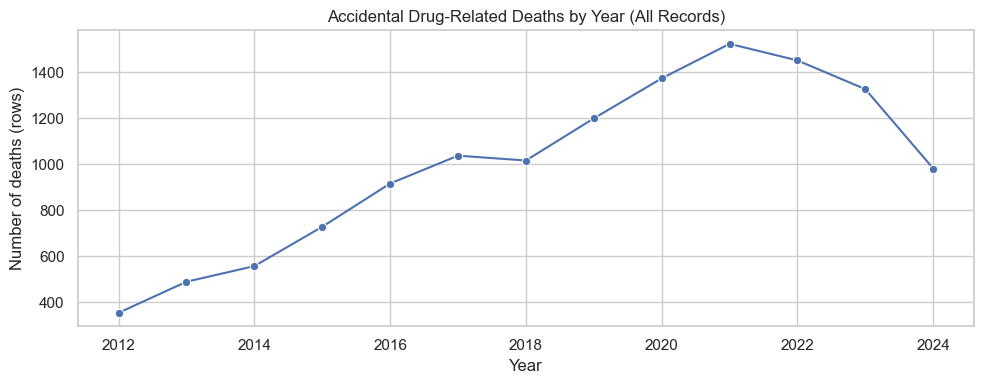

Year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Deaths,355,490,558,729,917,1038,1017,1200,1374,1524,1452,1327,982


In [ ]:
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
plt.title("Accidental Drug-Related Deaths by Year (All Records)")
plt.xlabel("Year")
plt.ylabel("Number of deaths (rows)")
save_fig("01_deaths_by_year.png")
plt.show()

display(year_counts.to_frame("Deaths").T)

Saved: outputs\02_age_distribution.png


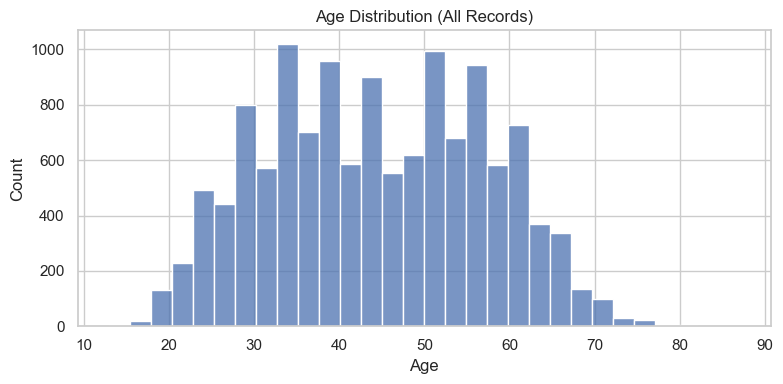

Saved: outputs\03_age_by_sex_boxplot.png


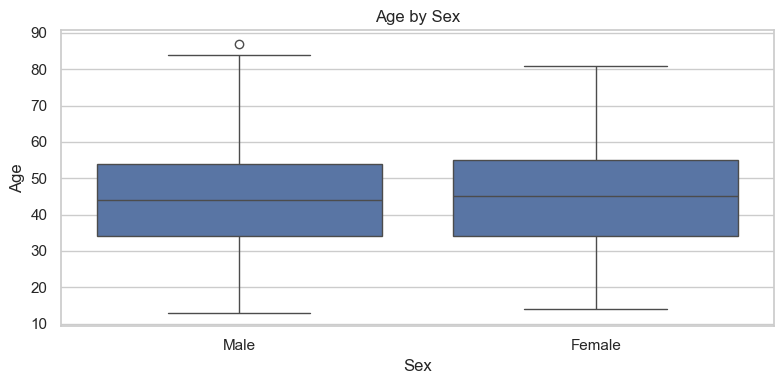

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"].dropna(), bins=30)
plt.title("Age Distribution (All Records)")
plt.xlabel("Age")
plt.ylabel("Count")
save_fig("02_age_distribution.png")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df[df["Sex"].isin(["Male","Female"])], x="Sex", y="Age")
plt.title("Age by Sex")
save_fig("03_age_by_sex_boxplot.png")
plt.show()

Saved: outputs\04_top_substances.png


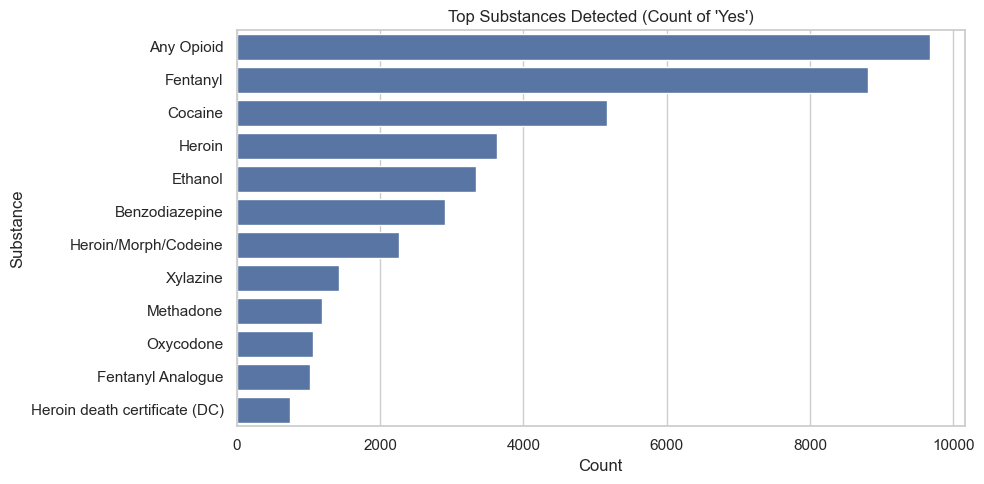

,Detected_Count
Any Opioid,9673
Fentanyl,8811
Cocaine,5164
Heroin,3636
Ethanol,3332
Benzodiazepine,2911
Heroin/Morph/Codeine,2263
Xylazine,1420
Methadone,1191
Oxycodone,1070


In [ ]:
sub_totals = df[[c for c in SUBSTANCE_COLS if c in df.columns]].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=sub_totals.head(12).values, y=sub_totals.head(12).index)
plt.title("Top Substances Detected (Count of 'Yes')")
plt.xlabel("Count")
plt.ylabel("Substance")
save_fig("04_top_substances.png")
plt.show()

display(sub_totals.head(15).to_frame("Detected_Count"))

Saved: outputs\05_selected_substance_trends.png


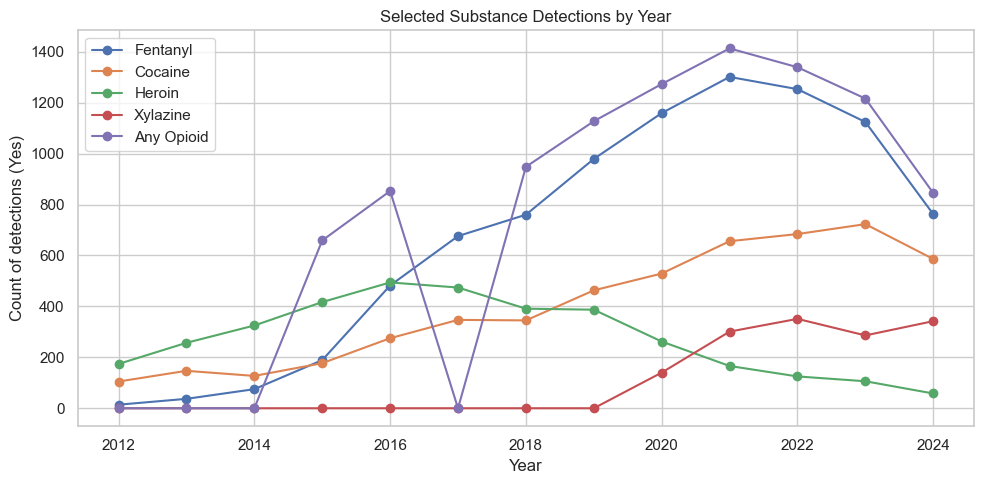

,Fentanyl,Cocaine,Heroin,Xylazine,Any Opioid
Year,,,,,
2015,189,177,417,0,659
2016,482,275,494,0,853
2017,676,347,474,0,0
2018,760,345,391,0,948
2019,979,463,387,0,1127
2020,1159,529,262,140,1273
2021,1301,656,166,301,1413
2022,1253,684,125,351,1339
2023,1124,723,106,286,1216


In [ ]:
trend_subs = ["Fentanyl", "Cocaine", "Heroin", "Xylazine", "Any Opioid"]
trend_subs = [c for c in trend_subs if c in df.columns]

year_sub = df.groupby("Year")[trend_subs].sum().sort_index()

plt.figure(figsize=(10,5))
for c in trend_subs:
    plt.plot(year_sub.index, year_sub[c], marker="o", label=c)
plt.title("Selected Substance Detections by Year")
plt.xlabel("Year")
plt.ylabel("Count of detections (Yes)")
plt.legend()
save_fig("05_selected_substance_trends.png")
plt.show()

display(year_sub.tail(10))

## Task 1: Research Questions + Hypotheses

**Research Questions (RQ):**
- **RQ1:** How have accidental drug-related deaths changed over time (2012–2024)?
- **RQ2:** Which substances are most frequently detected, and how have key substances (Fentanyl, Heroin, Cocaine, Xylazine) changed over time?
- **RQ3:** Is Fentanyl detection associated with Sex (Male vs Female)?
- **RQ4:** Do cases involving Fentanyl differ in Age compared to cases without Fentanyl?

**Hypothesis (for testing):**
- **H0 (Null):** Fentanyl detection is independent of Sex (no association).
- **H1 (Alternative):** Fentanyl detection is associated with Sex (there is an association).


Saved: outputs\06_rq1_deaths_by_year_date_of_death.png


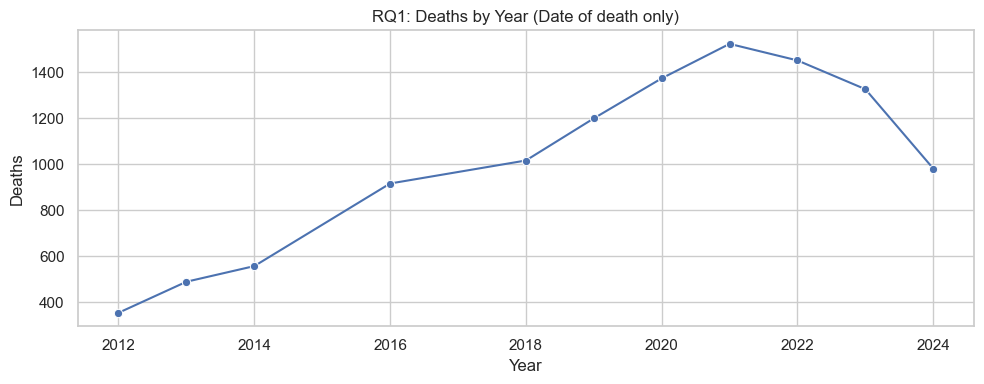

Saved: outputs\07_rq1_deaths_by_yearmonth.png


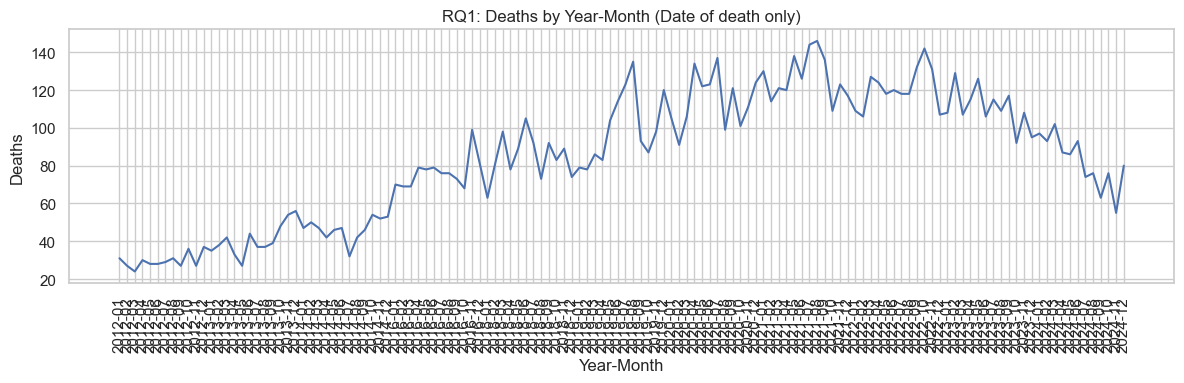

,Deaths (Date of death only)
Year,
2012,355
2013,490
2014,558
2016,917
2018,1017
2019,1200
2020,1374
2021,1524
2022,1452


In [ ]:
# Use Date Type "Date of death" only (often cleaner for trends)
df_death = df[df["Date Type"].str.contains("death", case=False, na=False)].copy()

rq1_year = df_death["Year"].value_counts().sort_index()
rq1_month = df_death["YearMonth"].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.lineplot(x=rq1_year.index, y=rq1_year.values, marker="o")
plt.title("RQ1: Deaths by Year (Date of death only)")
plt.xlabel("Year")
plt.ylabel("Deaths")
save_fig("06_rq1_deaths_by_year_date_of_death.png")
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(x=rq1_month.index, y=rq1_month.values)
plt.title("RQ1: Deaths by Year-Month (Date of death only)")
plt.xlabel("Year-Month")
plt.ylabel("Deaths")
plt.xticks(rotation=90)
save_fig("07_rq1_deaths_by_yearmonth.png")
plt.show()

display(rq1_year.to_frame("Deaths (Date of death only)"))

,Detected_Count (Date of death only)
Any Opioid,9014
Fentanyl,7946
Cocaine,4640
Ethanol,2866
Heroin,2745
Benzodiazepine,2360
Heroin/Morph/Codeine,1827
Xylazine,1420
Methadone,1020
Fentanyl Analogue,882


Saved: outputs\08_rq2_substance_share_by_year.png


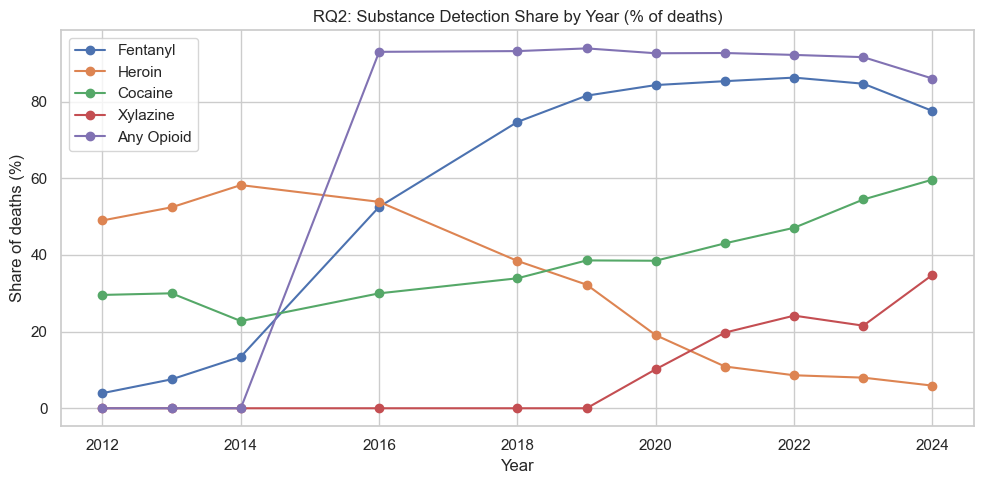

,Fentanyl,Heroin,Cocaine,Xylazine,Any Opioid
Year,,,,,
2012,3.9,49.0,29.6,0.0,0.0
2013,7.6,52.4,30.0,0.0,0.0
2014,13.4,58.2,22.8,0.0,0.0
2016,52.6,53.9,30.0,0.0,93.0
2018,74.7,38.4,33.9,0.0,93.2
2019,81.6,32.2,38.6,0.0,93.9
2020,84.4,19.1,38.5,10.2,92.6
2021,85.4,10.9,43.0,19.8,92.7
2022,86.3,8.6,47.1,24.2,92.2


In [ ]:
# Top substances overall (Date of death only)
sub_totals_death = df_death[[c for c in SUBSTANCE_COLS if c in df_death.columns]].sum().sort_values(ascending=False)
display(sub_totals_death.head(15).to_frame("Detected_Count (Date of death only)"))

# Substance share over time (% of deaths each year)
share_cols = ["Fentanyl", "Heroin", "Cocaine", "Xylazine", "Any Opioid"]
share_cols = [c for c in share_cols if c in df_death.columns]

year_shares = df_death.groupby("Year")[share_cols].mean().sort_index()  # mean of 0/1 = share

plt.figure(figsize=(10,5))
for c in share_cols:
    plt.plot(year_shares.index, year_shares[c]*100, marker="o", label=c)
plt.title("RQ2: Substance Detection Share by Year (% of deaths)")
plt.xlabel("Year")
plt.ylabel("Share of deaths (%)")
plt.legend()
save_fig("08_rq2_substance_share_by_year.png")
plt.show()

display((year_shares*100).round(1))

Fentanyl,0,1
Sex,,
Female,1047,1882
Male,2201,6055


Chi-square test (Sex vs Fentanyl)
Chi2 = 86.18683013345932
dof  = 1
p    = 1.6371432259310927e-20
Cramer's V = 0.08778139127322572
Decision at alpha=0.05: Reject H0 (significant association)
Saved: outputs\09_rq3_fentanyl_rate_by_sex.png


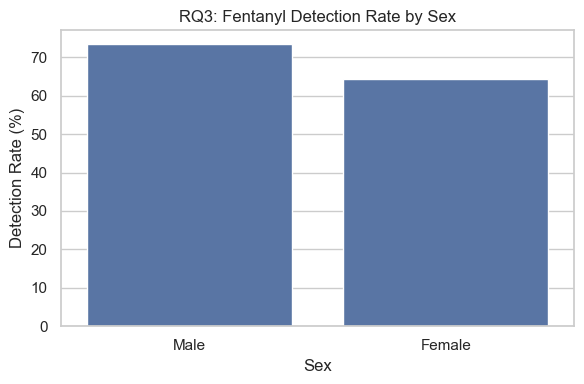

,Fentanyl Detection Rate (%)
Sex,
Male,73.34
Female,64.25


In [ ]:
# Contingency table (Male/Female only for clean test)
df_test = df_death[df_death["Sex"].isin(["Male", "Female"])].copy()

ct = pd.crosstab(df_test["Sex"], df_test["Fentanyl"])
display(ct)

chi2, p_value, dof, expected = chi2_contingency(ct)

# Effect size: Cramer's V
n = ct.values.sum()
phi2 = chi2 / n
r, k = ct.shape
cramers_v = np.sqrt(phi2 / (min(k-1, r-1)))

print("Chi-square test (Sex vs Fentanyl)")
print("Chi2 =", chi2)
print("dof  =", dof)
print("p    =", p_value)
print("Cramer's V =", cramers_v)

# Decision (alpha=0.05)
alpha = 0.05
decision = "Reject H0 (significant association)" if p_value < alpha else "Fail to reject H0 (no significant association)"
print("Decision at alpha=0.05:", decision)

# Visual: Fentanyl detection rate by sex
rates = df_test.groupby("Sex")["Fentanyl"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=rates.index, y=rates.values*100)
plt.title("RQ3: Fentanyl Detection Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Detection Rate (%)")
save_fig("09_rq3_fentanyl_rate_by_sex.png")
plt.show()

display((rates*100).round(2).to_frame("Fentanyl Detection Rate (%)"))

Counts (Date of death only):
Fentanyl=1: 7945
Fentanyl=0: 3250

Age summary:


,Group,Mean,Median,Std
0,Fentanyl=1,44.35,44.0,12.61
1,Fentanyl=0,45.66,47.0,12.87


RQ4: Age difference tests (Fentanyl vs Not)
Mann-Whitney U: 12117647.5 p = 3.2180863101742877e-07
Welch t-test:   -4.91640208618843 p = 9.052289428564697e-07
Cohen's d: -0.10324193232474355
Saved: outputs\10_rq4_age_kde_fentanyl_vs_not.png


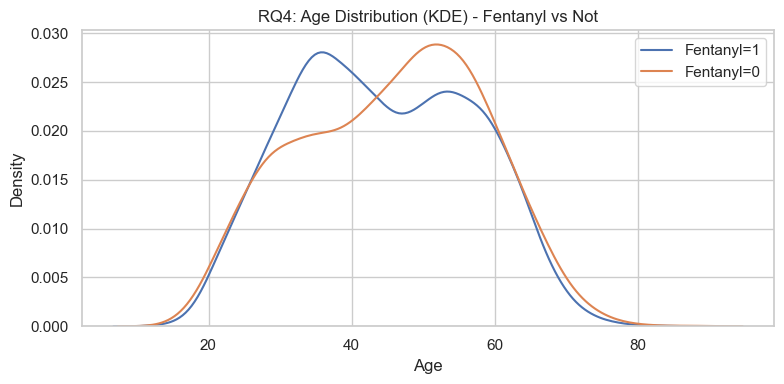

Saved: outputs\11_rq4_age_boxplot_fentanyl.png


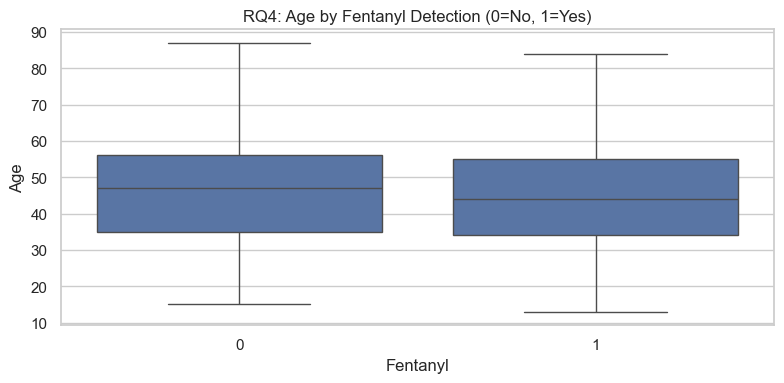

In [ ]:
# Compare age distributions between fentanyl detected vs not detected
age_f = df_death.loc[(df_death["Fentanyl"] == 1) & df_death["Age"].notna(), "Age"]
age_nf = df_death.loc[(df_death["Fentanyl"] == 0) & df_death["Age"].notna(), "Age"]

print("Counts (Date of death only):")
print("Fentanyl=1:", len(age_f))
print("Fentanyl=0:", len(age_nf))

print("\nAge summary:")
display(pd.DataFrame({
    "Group": ["Fentanyl=1", "Fentanyl=0"],
    "Mean": [age_f.mean(), age_nf.mean()],
    "Median": [age_f.median(), age_nf.median()],
    "Std": [age_f.std(ddof=1), age_nf.std(ddof=1)]
}).round(2))

# Non-parametric test: Mann-Whitney U
u_stat, p_u = stats.mannwhitneyu(age_f, age_nf, alternative="two-sided")

# Welch t-test
t_stat, p_t = stats.ttest_ind(age_f, age_nf, equal_var=False)

def cohens_d(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na, nb = len(a), len(b)
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((na-1)*sa**2 + (nb-1)*sb**2) / (na+nb-2))
    return (a.mean() - b.mean()) / sp

d = cohens_d(age_f, age_nf)

print("RQ4: Age difference tests (Fentanyl vs Not)")
print("Mann-Whitney U:", u_stat, "p =", p_u)
print("Welch t-test:  ", t_stat, "p =", p_t)
print("Cohen's d:", d)

# Visualize distributions
plt.figure(figsize=(8,4))
sns.kdeplot(age_f, label="Fentanyl=1")
sns.kdeplot(age_nf, label="Fentanyl=0")
plt.title("RQ4: Age Distribution (KDE) - Fentanyl vs Not")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
save_fig("10_rq4_age_kde_fentanyl_vs_not.png")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df_death[df_death["Age"].notna()], x="Fentanyl", y="Age")
plt.title("RQ4: Age by Fentanyl Detection (0=No, 1=Yes)")
save_fig("11_rq4_age_boxplot_fentanyl.png")
plt.show()

,Top Death Counties (Date of death only)
Death County,
NEW HAVEN,1911
HARTFORD,1896
FAIRFIELD,1012
NEW LONDON,585
LITCHFIELD,324
MIDDLESEX,250
WINDHAM,208
TOLLAND,155
USA,1


Saved: outputs\12_top_death_counties.png


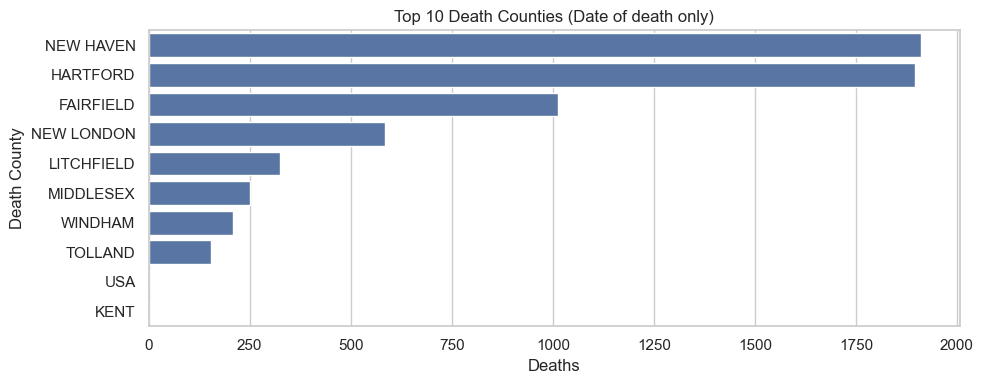

Saved: outputs\13_poly_drug_count_distribution.png


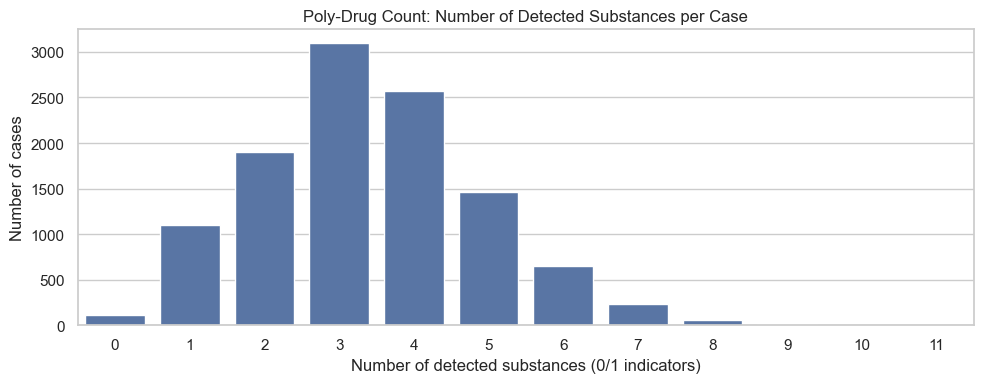

,Poly-Drug Summary
count,11196.000000
mean,3.385048
std,1.515531
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,11.000000


In [ ]:
# Top death counties
top_counties = df_death["Death County"].value_counts().head(10)
display(top_counties.to_frame("Top Death Counties (Date of death only)"))

plt.figure(figsize=(10,4))
sns.barplot(x=top_counties.values, y=top_counties.index)
plt.title("Top 10 Death Counties (Date of death only)")
plt.xlabel("Deaths")
plt.ylabel("Death County")
save_fig("12_top_death_counties.png")
plt.show()

# Poly-drug distribution
plt.figure(figsize=(10,4))
sns.countplot(x=df_death["Num_Substances"])
plt.title("Poly-Drug Count: Number of Detected Substances per Case")
plt.xlabel("Number of detected substances (0/1 indicators)")
plt.ylabel("Number of cases")
save_fig("13_poly_drug_count_distribution.png")
plt.show()

display(df_death["Num_Substances"].describe().to_frame("Poly-Drug Summary"))

In [ ]:
# Collect key tables
results = {}
results["Deaths_by_Year"] = rq1_year.to_frame("Deaths")
results["Top_Substances"] = sub_totals_death.head(20).to_frame("Detected_Count")
results["Substance_Share_by_Year_percent"] = (year_shares*100).round(2)
results["Sex_vs_Fentanyl_crosstab"] = ct
results["Top_Death_Counties"] = top_counties.to_frame("Deaths")

# Export to Excel
excel_path = OUTPUT_DIR / "section1_results_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, table in results.items():
        table.to_excel(writer, sheet_name=name[:31])
print("Saved tables to:", excel_path)

# Save cleaned dataset
clean_path = OUTPUT_DIR / "cleaned_accidental_drug_deaths_2012_2024.csv"
df_death.to_csv(clean_path, index=False)
print("Saved cleaned dataset to:", clean_path)

Saved tables to: outputs\section1_results_tables.xlsx
Saved cleaned dataset to: outputs\cleaned_accidental_drug_deaths_2012_2024.csv


Saved workflow diagram to: outputs\14_workflow_diagram.png


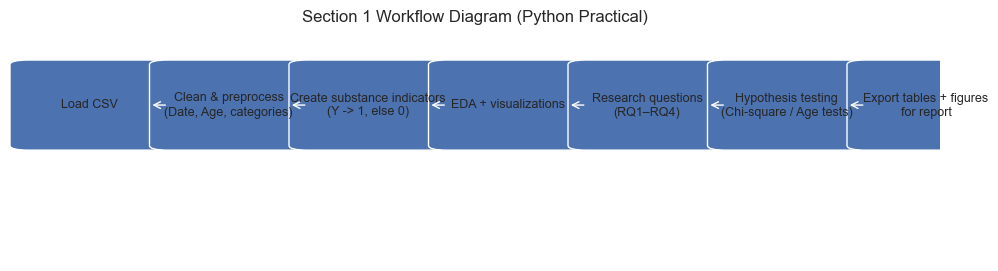

In [ ]:
import matplotlib.patches as patches

plt.figure(figsize=(12,3))
ax = plt.gca()
ax.set_axis_off()

steps = [
    "Load CSV",
    "Clean & preprocess\n(Date, Age, categories)",
    "Create substance indicators\n(Y -> 1, else 0)",
    "EDA + visualizations",
    "Research questions\n(RQ1–RQ4)",
    "Hypothesis testing\n(Chi-square / Age tests)",
    "Export tables + figures\nfor report"
]

x0, y0 = 0.02, 0.5
w, h = 0.13, 0.35
gap = 0.02

for i, s in enumerate(steps):
    xi = x0 + i*(w+gap)
    rect = patches.FancyBboxPatch((xi, y0), w, h, boxstyle="round,pad=0.02")
    ax.add_patch(rect)
    ax.text(xi + w/2, y0 + h/2, s, ha="center", va="center", fontsize=9)

    if i < len(steps)-1:
        ax.annotate("", xy=(xi+w, y0+h/2), xytext=(xi+w+gap, y0+h/2),
                    arrowprops=dict(arrowstyle="->"))

plt.title("Section 1 Workflow Diagram (Python Practical)", fontsize=12)
workflow_path = OUTPUT_DIR / "14_workflow_diagram.png"
plt.savefig(workflow_path, dpi=200, bbox_inches="tight")
print("Saved workflow diagram to:", workflow_path)
plt.show()